In [1]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request
from collections import Counter
import pandas as pd

import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

GREW_PATTERN = "pattern{X[upos<>PUNCT]}"
PATTERNS_TEXT_FILE = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt"
TREEBANK = "/Users/madalina/Documents/PHD/code/data/small_test/UD_French-GSD"


corpus = tod.corpus.Corpus(
            treebank_path=TREEBANK,
            grew_pattern=GREW_PATTERN,
            patterns_text_file=PATTERNS_TEXT_FILE,
            use_sud=False,
            matrix_type="coverage",
            excluded_feature_patterns=[r"own"],
            included_feature_patterns=[r"upos=", 
                                        r"position=", 
                                        r"rel_shallow=",
                                        r"Abbr=", 
                                        r"Aspect=",  
                                        r"Animacy=",  
                                        r"Case=",  
                                        r"Clusivity=",  
                                        r"Definite=",  
                                        r"Deixis=", 
                                        r"DeixisRef",  
                                        r"Evident=",  
                                        r"Negation=",
                                        r"Number=",  
                                        r"Gender=",  
                                        r"Degree=",  
                                        r"ExtPos=", 
                                        r"Foreign=", 
                                        r"Mood",  
                                        r"NounClass=",  
                                        r"NumType=",  
                                        r"Person=",  
                                        r"Polarity=", 
                                        r"Polite=",  
                                        r"Poss=",  
                                        r"PronType=",  
                                        r"Reflex=",  
                                        r"Tense=",  
                                        r"Typo=",     
                                        r"VerbForm=",  
                                        r"Voice=",   ])

connected to port: 63603


In [2]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(corpus.feature_matrix)

In [3]:
import numpy as np
results = []
lex_units_with_different_neighbours = set()
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        if neighbour_category != current_category and similarity_matrix[idx][neighbour_idx] > 0.5:
            diff = np.abs(corpus.feature_matrix[idx] - corpus.feature_matrix[neighbour_idx])
            closest_features_idx= np.argsort(diff)[:-6:-1]
            closest_features = [corpus._idx2feature[i] for i in closest_features_idx]
                
            results.append({
                "lex_unit": lex_unit,
                "neighbour_lex_unit": corpus._idx2lexunit[neighbour_idx],
                "distance": similarity_matrix[idx][neighbour_idx],
                "closest_features": closest_features,
                
            })
            lex_units_with_different_neighbours.add(lex_unit)
    

for r in results:
    print(r)   

{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('di', 'ADP'), 'distance': 0.9467013753043609, 'closest_features': ['node:X:next:upos=PROPN', 'node:X:parent:upos=PROPN', 'node:X:prev:Number=Sing', 'node:X:prev:upos=PROPN', 'node:X:prev:Gender=Fem']}
{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('en', 'ADP'), 'distance': 0.7006773890497091, 'closest_features': ['node:X:parent:upos=PROPN', 'node:X:prev:upos=PROPN', 'node:X:next:upos=PROPN', 'node:X:parent:position=after', 'node:X:next:upos=NUM']}
{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('chez', 'ADP'), 'distance': 0.6734121231644671, 'closest_features': ['node:X:prev:upos=PROPN', 'node:X:parent:position=after', 'node:X:parent:upos=PROPN', 'node:X:next:upos=PROPN', 'node:X:next:upos=DET']}
{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('via', 'ADP'), 'distance': 0.6374743503720702, 'closest_features': ['node:X:next:upos=PROPN', 'node:X:parent:upos=PROPN', 'node:X:prev:upos=PROPN', 'node:X:parent:position=after', '

In [4]:
from scipy.stats import entropy
scores = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    purity_top, purity_bottom = 0, 0
    category_weights = {}
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour # the sum of all the inverse weights
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour

        if neighbour_category == current_category:
            purity_top += distance_to_neighbour

    purity_score = purity_top / purity_bottom

    probabilities = [v / purity_bottom for v in category_weights.values()]
    entropy_score = entropy(probabilities)
    
    scores[lex_unit] = {}
    scores[lex_unit]["purity"] = purity_score
    scores[lex_unit]["entropy"] = entropy_score

    rival_cat = None
    rival_weight = 0

    for cat, w in category_weights.items():
        if cat != current_category and w > rival_weight:
            rival_weight = w
            rival_cat = cat

    scores[lex_unit]["rival_category"] = rival_cat
    scores[lex_unit]["rival_weight_ratio"] = rival_weight / purity_bottom if purity_bottom > 0 else 0
    

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the 'Rival' for each unit
matrix_data = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    
    # We only care about units that have some level of 'pull' from others
    if stats['rival_category'] is not None:
        
       matrix_data.append(
           {
               "Original": current_cat,
               "Rival": stats['rival_category']
           }
       )
df_transitions = pd.DataFrame(matrix_data)
transition_matrix = pd.crosstab(
    df_transitions['Original'], 
    df_transitions['Rival'], 
    normalize='index'
)


In [11]:
features = corpus._idx2feature
uposes = set()
for k, v in features.items():
    if "upos" in v:
        upos = v.split("upos=")[1]
        uposes.add(upos)

In [13]:
uposes = sorted(list(uposes))

In [16]:
all_overlaps = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]

    idx = corpus._lexunit2idx[lex_unit]

    threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]

    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x],
        reverse=True
    )[:20]

    purity_bottom = 0
    category_weights = {}
    
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour
        
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour
    
    for rival_cat, weight in category_weights.items():
        if rival_cat != current_cat:
            all_overlaps.append({
                "Original": current_cat,
                "Rival": rival_cat,
                "Weight": weight / purity_bottom if purity_bottom > 0 else 0
            })

df_overlaps = pd.DataFrame(all_overlaps)
# Group by Original and Rival, then sum the weights and normalize
transition_matrix = df_overlaps.groupby(['Original', 'Rival'])['Weight'].sum().unstack(fill_value=0)
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

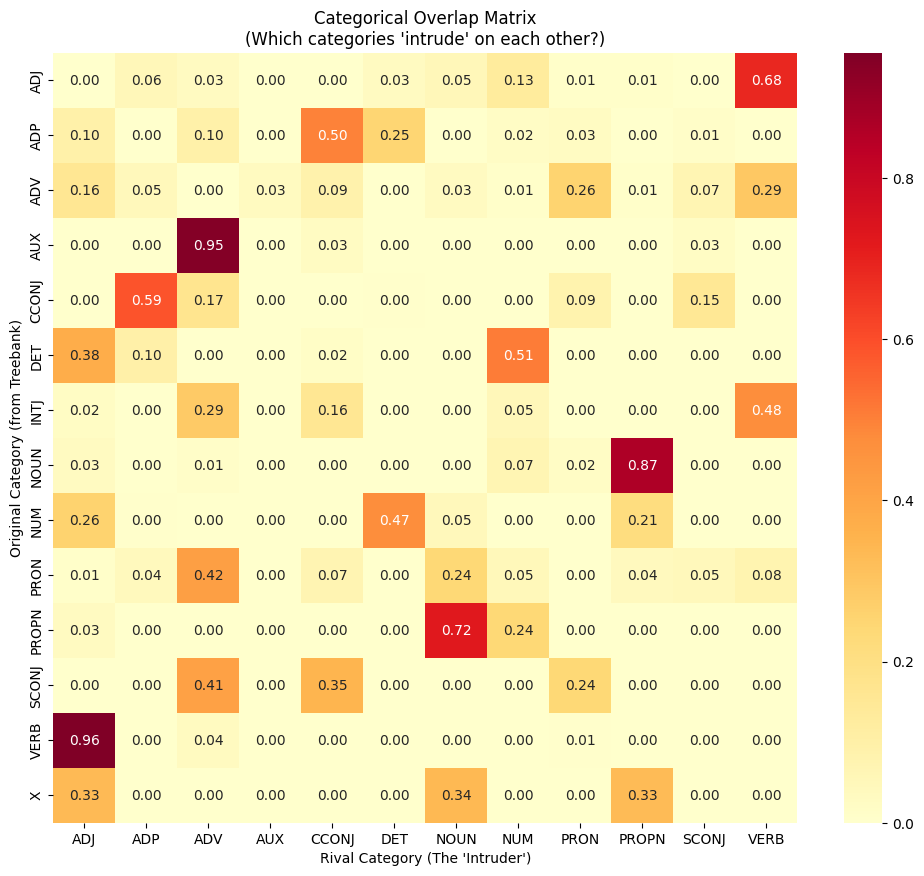

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    transition_matrix, 
    annot=True,      # Show the numbers in the cells
    cmap="YlOrRd",   # Color gradient: Yellow (low) to Red (high)
    fmt=".2f"        # Format to 2 decimal places
)

plt.title("Categorical Overlap Matrix\n(Which categories 'intrude' on each other?)")
plt.ylabel("Original Category (from Treebank)")
plt.xlabel("Rival Category (The 'Intruder')")
plt.show()

In [19]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Finds the words from original_cat most pulled toward rival_cat."""
    matches = []
    
    for (word, o_cat), data in scores_dict.items():
        if o_cat == original_cat and data["rival_category"] == rival_cat:
            matches.append((word, data["purity"], data["entropy"]))
            
    # Sort by lowest purity (the ones most 'pulled' away)
    matches.sort(key=lambda x: x[1])
    
    return matches[:top_n]

# Example: Who are the Verbs that look like Adjectives?
category_to_compare_1 = "ADJ"
category_to_compare_2 = "VERB"
bridge_verbs = get_top_bridge_words(scores, category_to_compare_1, category_to_compare_2)
print(f"Top {category_to_compare_1} -> {category_to_compare_2} bridge words: ")
print(f"Word \t Purity \t Entropy")
for v in bridge_verbs:
    print(v)

Top ADJ -> VERB bridge words: 
Word 	 Purity 	 Entropy
('issu', 0.2098265389306549, 0.5137267569362709)
('censé', 0.21209275393465787, 0.5167162459333975)
('présent', 0.2712549313562604, 0.5845030320148994)
('capable', 0.31664181246512796, 0.6243121889552994)
('responsable', 0.3180355496945233, 0.6253798333398618)
('originaire', 0.36783384877398334, 0.8382844212795169)
('quel', 0.4226432656401877, 0.6811308434013051)
('prêt', 0.42432405722185995, 0.6816493491978897)
('endémique', 0.4270936129806876, 0.6824785034848724)
('disponible', 0.5310790234749896, 0.6912141232680584)
('impossible', 0.5421790732394103, 0.6895847999224625)
('probable', 0.5935224816617969, 0.6755508160038131)
('âgé', 0.6356916236789271, 0.6558568672858043)
('accessible', 0.6358639246138331, 0.6557608810358698)
('visible', 0.636967883404564, 0.6551428386218421)
('possible', 0.6426756782280819, 0.6518631519542215)
('proche', 0.6880636049911147, 0.6206412565494006)
('satisfait', 0.6889033342368439, 0.6199753183859023)
